# ToxiScan — Molecular Toxicity Analysis 

## Introduction

### 🔬About this Notebook
This interactive Jupyter Notebook presents **ToxiScan**, a Python package designed to evaluate  the toxicity of molecules. By simply entering a molecule, Toxiscan retrieves its structure from the PubChem database. From this, it visualizes the molecule in 2D an 3D, highlights and detects toxic functional groups (the **toxicophores**), and computes different toxicity scores.

This package was created as a collaborative project for the EPFL course Practical Programming in Chemistry.

### 🌱Why does molecular toxicity matter? 
In drug discovery and chemical safety, identifying toxic functional groups early is crucial. **Toxicophores** such as nitro groups, epoxides or aldehydes are specific chemical substructures known to cause adverse biological effects. ToxiScan automates their detection to help chemists quickly flag potentially harmful molecules. 
Avoiding the synthesis of toxic molecules is also a **green chemistry** approach, it saves resources and reduces dangerous chemical waste. 

### 💡Why choose ToxiScan? 
Several tools already exist for toxicity prediction, such as **SwissADME**, **pkCSM**, or **FAF-Drugs**. The real added value of ToxiScan is **accessibility and integration**:
- ToxiScan is a **pip-installable Python package** usable in any cheminformatics workflow
- Ideal for analyzing **entire lists of molecules** automatically, not just one at a time 
- **Open source and transparent**, you can see exactly which rules are applied, not a black box

*ToxiScan does not reinvent the wheel, but makes toxicity analysis **accessible in Python**, integrable in any cheminformatics pipeline.*

## ⚙️Setup

Please run the following cell to import all the functions from ToxiScan and ensure the code runs properly. The package relies on **RDKit** for molecular parsing and substructure matching, and the **PubChem REST API** for retrieving molecular data.

In [ ]:
from toxiscan import (get_smiles, get_molecule_info, find_toxicophores,
                      count_toxicophores, remove_redundant_toxicophores,
                      toxicity_approximation, compute_properties,
                      interpret_properties, properties_toxicity,
                      draw_molecule, draw_molecule_3d)

## 📖Methods

In this section, each function of ToxiScan is presented with an explanation of what it does, how it works, and an example output. 

### 1. Retrieve a molecule from PubChem🔍

ToxiScan connects to the **PubChem** database via its REST API to fetch this information automatically from a molecule name.

**1️⃣ Get the SMILES of a molecule** 

**What is a SMILES?**
SMILES (Simplified Molecular Input Line Entry System) is a notation that encodes the structure of a molecule as a string of characters. 
For example, aspirin is encoded as `CC(=O)Oc1ccccc1C(=O)O`

`get_smiles(molecule_name)` takes a molecule name, IUPAC name, or CAS number and returns its SMILES string, fetched from PubChem.

#### Example output:
For aspirin you should get: CC(=O)Oc1ccccc1C(=O)O

**2️⃣ Get full molecular information**

The function `get_molecule_info(molecule_name)` takes a molecule name (str), IUPAC name, or CAS number and returns a dictionary with its basic chemical information (name, molecular formula, molecular weight, IUPAC name and SMILES) from the **PubChem** database. 

**How does it work?**
The function sends a GET request to the PubChem REST API using the molecule name, then parses the JSON response to extract the relevant chemical properties. 

#### Example output
```
For aspirin, you should get: 

```

Name: aspirin

Formula: C9H8O4

Molecular weight: 180.2 g/mol

IUPAC name: 2-acetyloxybenzoic acid

SMILES: CC(=O)Oc1ccccc1C(=O)O

```

**Let's try it! Run the cell below:**

In [9]:
molecule_name = "aspirin"
info = get_molecule_info(molecule_name)
print(f"Name: {info['name']}")
print(f"Formula: {info['formula']}")
print(f"Molecular weight: {info['molecular_weight']} g/mol")
print(f"IUPAC name: {info['iupac_name']}")
print(f"SMILES: {info['smiles']}")

Name: aspirin
Formula: C9H8O4
Molecular weight: 180.16 g/mol
IUPAC name: 2-acetyloxybenzoic acid
SMILES: CC(=O)OC1=CC=CC=C1C(=O)O


### 2. Detect toxicophores☠️ 

`find_toxicophores(smiles)` takes a SMILES string of a molecule and returns a dictionary where keys are toxicophore names and values are lists of atom indices where each toxicophore was found. Returns an empty dictionary if no toxicophores are detected.

Thanks to a dictionary `TOXICOPHORES`, ToxiScan recognizes **25 toxicophores** organized in 8 categories: 

| Category | Examples |
|----------|----------|
| Nitrogen-based | Nitro group, Nitroso group, Primary aniline, Hydrazine, Aromatic azo, N-oxide, Hydroxamic acid |
| Carbonyl-based | Aldehyde, Acyl halide, Anhydride, Alpha halo ketone, Beta lactone |
| Electrophilic | Epoxide, Isocyanate, Michael acceptor, Aziridine, Activated alkyne |
| Halogen-based | Alkyl halide, Allylic halide |
| Sulfur-based | Thiol, Thiocarbonyl |
| Peroxide | Peroxide |
| Polycyclic aromatic | Quinone, Coumarin | 
| Reactive oxygen | Hydroperoxide |

**How does it work?**
For each of the 25 toxicophores, the function converts the SMARTS pattern to an RDKit mol object and searches for substructures matches in the molecule. Matched atom indices are collected and returned. Before returning the results, `remove_redundant_toxicophores` is 
called to remove any toxicophores whose atoms are already fully contained within a larger detected group, avoiding double-counting (e.g. a nitroso group can be detected both as nitroso and as a part of a nitro group). 

#### Example output
For aspirin, you should get: 

````

No toxicophores detected in aspirin.

```

**Let's try it! Run the cell below:**

In [10]:
smiles = info["smiles"]
toxicophores_found = find_toxicophores(smiles)

if toxicophores_found:
    print(f"Toxicophores detected in {molecule_name}:")
    for name, atoms in toxicophores_found.items():
        print(f"  - {name} (atoms: {atoms})")
else:
    print(f"No toxicophores detected in {molecule_name}.")

No toxicophores detected in aspirin.


### 3. Visualize the molecule in 2D

The function `draw_molecule(smiles, toxicophores_found)` takes a SMILES string and the toxicophores dictionary, displays the molecule as an SVG image and highlights all detected toxic groups in **yellow-green**.

**How does it work?**
The function collects all atom indices from the toxicophores dictionary, the uses RDKit's `MolDraw2DSVG` with a custom yellow-green highlight color (RGB: 0.6, 0.9, 0.2) to render the molecule. 

#### Expected output
You should see the molecule drawn with the toxic atoms highlighted in yellow-green. 

**Let's try it! Run the cell below:**

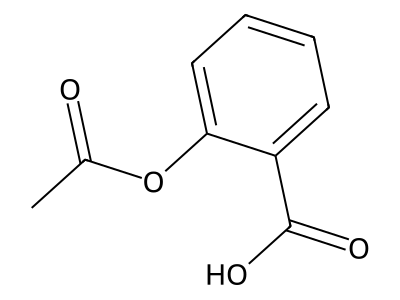

In [11]:
from IPython.display import SVG
draw_molecule(smiles, toxicophores_found)
with open("molecule.svg") as f:
    display(SVG(f.read()))

As seen earlier, aspirin contains no toxicophores, so no atoms are highlighted. In the next section, we demonstrate ToxiScan on molecules that do contain toxic functional groups.

### 4. Visualize the molecule in 3D🌐

`draw_molecule_3d(smiles, toxicophores_found)` takes a SMILES string and the toxicophores dictionary , and generates an **interactive 3D visualization** of the molecule with toxic atoms highlighted in green. 

**How does it work?**
The function generates 3D coordinates using RDKit's `EmbedMolecule`, then passes the mol block to py3Dmol for interactive rendering. All atoms are shown as ball-and-stick, and toxic atoms are highlighted in green. 

### Expected output 
You should see an interactive 3D representation of the molecule with the toxic atoms highlighted in green. You can rotate and zoom using your mouse. 

**Let's try it! Run the cell below:**

In [ ]:
from IPython.display import HTML
html_3d = draw_molecule_3d(smiles, toxicophores_found)
HTML(html_3d)

### 5. Compute the toxicity score📊

`toxicity_approximation(smiles)` takes a SMILES string and returns a float representing a normalized toxicity score based on the detected toxicophores. 

**How does it work?**
Each toxicophore is assigned a **weight** based on its known electrophilic reactivity: 

| Weight | Toxicophores |
|--------|-------------|
| 1 — mild | Primary aniline, N-oxide, Hydroxamic acid, Alkyl halide, Thiol, Thiocarbonyl, Coumarin |
| 2 — moderate | Nitro group, Nitroso group, Hydrazine, Aromatic azo, Aldehyde, Anhydride, Michael acceptor, Activated alkyne, Allylic halide, Quinone |
| 3 — high | Acyl halide, Alpha halo ketone, Beta lactone, Epoxide, Isocyanate, Aziridine, Peroxide, Hydroperoxide |

The total weighted score is then divided by the number of atoms in the molecule, so that larger molecules are not unfairly penalized compared to smaller ones. 

### Example output
For aspirin,
```
Toxicity score: 0.0000
Number of toxicophores detected: 0
```

**Let's try it! Run the cell below:**

In [15]:
score = toxicity_approximation(smiles)
n_tox = count_toxicophores(smiles)
print(f"Toxicity score of {molecule_name}: {score:.4f}")
print(f"Number of toxicophores detected: {n_tox}")

Toxicity score of aspirin: 0.0000
Number of toxicophores detected: 0


Since no toxicophores were detected, the toxicophore-based score is 0. However, as shown in the next section, the  toxicity score that accounts for physicochemical properties will therefore not be zero. 

### 6. Physicochemical properties & Lipinski's rules⚛️

`compute_properties(smiles)` takes a SMILES string and returns a dictionary of 5 physicochemical properties. 

`interpret_properties()` then classifies each value according to **Lipinski's rules**, and `properties_toxicity()` combines them into a single Lipinski score.

**How does it work?**
Each property is evaluated against predefined thresholds and assigned a weight (1 = insignificant, 2 = moderate, 3 = problematic). The weights are summed and normalized: `score = (sum - 5) / 10`.

| Property | Insignificant | Moderate | Problematic |
|----------|--------------|----------|-------------|
| log P | ≤ 3 | 3–5 | > 5 |
| Molecular weight | ≤ 300 | 300–500 | > 500 |
| TPSA | ≤ 60 | 60–140 | > 140 |
| H donors | ≤ 2 | 2–5 | > 5 |
| H acceptors | ≤ 5 | 5–10 | > 10 |

#### Example output 
For aspirin:
```
log P: 1.31 → insignificant
Molecular weight: 180.16 → insignificant
TPSA: 63.6 → moderate
H donors: 1 → insignificant
H acceptors: 3 → insignificant
Lipinski toxicity score: 0.1
```

In [14]:
properties = compute_properties(smiles)
interpreted = interpret_properties(properties)
lipinski_score = properties_toxicity(interpreted)

print(f"Physicochemical properties of {molecule_name}:")
for name, (value, level) in interpreted.items():
    print(f"  {name}: {value:.2f} → {level}")
print(f"\nLipinski toxicity score: {lipinski_score:.4f}")

Physicochemical properties of aspirin:
  log P: 1.31 → insignifiant
  Molecular weigh: 180.16 → insignifiant
  TPSA: 63.60 → moderate
  H Donors: 1.00 → insignifiant
  H Acceptors: 3.00 → insignifiant

Lipinski toxicity score: 0.1000


## 📈Results

To demonstrate ToxiScan's capabilities, we analyzed three molecules of increasing size and different toxicity complexity:

| Molecule | Formula | Size | Expected toxicity score | Expected Lipinski score |
|----------|---------|------|------------------|---------------|
| **Aspirin** | C9H8O4 | Small | Low | Low |
| **Carmustine** | C5H9Cl2N3O2 | Small | High | Low |
| **Zorubicine** | C17H12O6 | Large | Low | High |

The three molecules were chosen to cover a wide range of sizes and toxicity profiles, allowing us to validate that ToxiScan's scoring is consistent with known chemical toxicology. The following results are observed :

### 2D and 3D structures with highlighted toxicophores

- Aspirin:
![Aspirin](../assets/aspirin_2d_3d.jpeg)

- Carmustine:
![Carmustine](../assets/carmustine_2d_3d.jpeg)

- Zorubicine:
![Zorubicine](../assets/zorubicine_2d_3d.jpeg)

The 2D structures show each molecule and their structural differences: aspirin is compact and simple, carmustine contains two chlorine atoms visible in its chain and zorubicine displays a complex polycyclic aromatic structure. 
The 3D visualization reveal the spatial distribution of toxic atoms within each molecule which are highlighted in **green**. Aspirin shows no highlighted atoms — no toxicophores were detected in its structure. Carmustine, has several green atoms corresponding to its reactive chlorine-containing groups and nitroso group. Zorubicine shows no highlighted atoms either, despite being the largest and most complex molecule.

### Toxicity scores

| Molecule | Toxicophore score | Lipinski score |
|----------|------------------|---------------|
| Aspirin | 0.000🟢 | 0.100 🟡(Low)|
| Carmustine | 0.250🔴 (High)| 0.100🟡 (Low)|
| Zorubicine | 0.000🟢 | 0.800🔴 (Very high)|

Carmustine stands out with a toxicophore score of **0.250**, driven by its alkyl 
halide and nitroso groups — reactive electrophiles responsible for 
its DNA-alkylating mechanism. Aspirin and zorubicine both score 
**0.000**, meaning no SMARTS-detectable reactive groups were found.

The situation reverses for the Lipinski score: zorubicine scores **0.800** — the highest 
of the three — despite having no detected toxicophores. Its large 
polycyclic structure leads to an unfavorable physicochemical profile. 
Aspirin and carmustine both have a low score **0.100**, confirming their 
acceptable drug-likeness properties.

The two scores tell complementary stories: carmustine is dangerous 
through structural reactivity, zorubicine through its physicochemical 
profile, and aspirin is safe on both dimensions. This is why ToxiScan 
computes both. 

## Discussion

ToxiScan provides a fast structural screening of molecules based on toxicophore detection and physicochemical properties. The two 
complementary scores — the toxicophore-based score and the Lipinski score — offer different perspectives on molecular toxicity:

The **toxicophore score** captures the presence of reactive functional groups known to cause direct chemical toxicity through electrophilic reactivity. 
The **Lipinski score** complements this by evaluating drug-likeness and bioavailability-related properties.

### Limitations

- The functions used to retrieve the molecule from PubChem only accept the common name of the molecule as input. If the name is slightly different from what PubChem expects, the molecule will not be found.

- Both scores remain approximations. A molecule with a low toxicophore score may still be highly toxic through indirect mechanisms (e.g. receptor binding, metabolic activation), and two molecules with the same score can have very different actual toxicity in vivo. Lipinski's rules were not originally designed as a toxicity measure. Future improvements could include machine learning-based scoring or integration with experimental toxicity databases such as PubChem BioAssay or ChemTox.

Unlike existing web-based tools like SwissADME, ToxiScan is fully **integrable in Python workflows**, making it ideal for automated screening of large molecular libraries.


## Conclusion

### Main Features
- **Molecule retrieval**: fetch any molecule from PubChem by name
- **Toxicophore detection**: identify 25 known toxic functional groups 
using SMARTS patterns
- **2D & 3D Visualization**: highlight toxic fragments on the molecule
- **Toxicity scoring**: normalized score based on electrophilic 
reactivity weights
- **Lipinski scoring**: physicochemical property-based assessment

### Tools Used
- **RDKit**: molecule parsing, SMARTS substructure matching, 3D 
coordinate generation and physicochemical descriptors
- **PubChem REST API**: molecular data retrieval from molecule names
- **py3Dmol**: interactive 3D visualization
- **requests**: HTTP requests to the PubChem API
- **IPython**: inline visualization in the notebook

### Challenges Encountered
- **Toxicophore weights**: assigning meaningful weights required 
extensive research on electrophilic reactivity of functional groups
- **Redundant detection**: overlapping substructures caused the same 
atoms to be detected multiple times — solved with 
`remove_redundant_toxicophores`
- **SMARTS precision**: differentiating between similar groups 
(e.g. ester vs carboxylic acid) required careful SMARTS pattern design
- **Cross-platform environment**: the conda environment created on 
Windows caused compatibility issues on macOS (arm64)
- **GitHub collaboration**: managing push/pull conflicts and keeping 
the environment cross-platform was a steep learning curve

GreenChemPanion provides a fast and intuitive first screening tool 
to flag potentially toxic molecules. While scores are approximations, 
ToxiScan offers a useful, transparent and Python-native starting 
point for chemists in drug discovery or chemical safety assessment.

## References

- Kim, S.; Chen, J.; Cheng, T.; Gindulyte, A.; He, J.; He, S.; Li, Q.; Shoemaker, B. A.; Thiessen, P. A.; Yu, B.; Zaslavsky, L.; Zhang, J.; Bolton, E. E. PubChem 2023 update. Nucleic Acids Res. 2023, 51, D1373–D1380. https://doi.org/10.1093/nar/gkac956
- RDKit: Open-source cheminformatics. https://www.rdkit.org
- Streamlit. https://streamlit.io
- Rego, N.; Koes, D. 3Dmol.js: molecular visualization with WebGL. Bioinformatics 2015, 31, 1322–1324. https://doi.org/10.1093/bioinformatics/btu829
- Daina, A.; Michielin, O.; Zoete, V. SwissADME: a free web tool to evaluate pharmacokinetics, drug-likeness and medicinal chemistry friendliness of small molecules. Sci. Rep. 2017, 7, 42717. https://doi.org/10.1038/srep42717
- Pires, D. E. V.; Blundell, T. L.; Ascher, D. B. pkCSM: Predicting Small-Molecule Pharmacokinetic and Toxicity Properties Using Graph-Based Signatures. J. Med. Chem. 2015, 58, 4066–4072. https://doi.org/10.1021/acs.jmedchem.5b00104
- Lagorce, D.; Bouslama, L.; Becot, J.; Miteva, M. A.; Villoutreix, B. O. FAF-Drugs4: free ADME-tox filtering computations for chemical biology and early stages drug discovery. Bioinformatics 2017, 33, 3658–3660. https://doi.org/10.1093/bioinformatics/btx491
- Brenk, R.; Schipani, A.; James, D.; Krasowski, A.; Gilbert, I. H.; Frearson, J.; Wyatt, P. G. Lessons Learnt from Assembling Screening Libraries for Drug Discovery for Neglected Diseases. ChemMedChem 2008, 3, 435–444. https://doi.org/10.1002/cmdc.200700139
- Baell, J. B.; Holloway, G. A. New Substructure Filters for Removal of Pan Assay Interference Compounds (PAINS) from Screening Libraries and for Their Exclusion in Bioassays. J. Med. Chem. 2010, 53, 2719–2740. https://doi.org/10.1021/jm901137j
- Lipinski, C. A.; Lombardo, F.; Dominy, B. W.; Feeney, P. J. Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings. Adv. Drug Deliv. Rev. 2001, 46, 3–26. https://doi.org/10.1016/S0169-409X(00)00129-0

